## Importação de Pacotes e Funções Auxiliares

In [3]:
import re
import math
import unicodedata
import warnings
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.cm as cm
import seaborn as sns

import geopandas as gpd
from IPython.display import display

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

In [4]:
output_dir = Path("../results")
fig_dir = output_dir / "figures"
table_dir = output_dir / "tables"

fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

In [49]:
def normalize_text(value, title=False):
    value = str(value).strip().lower()
    value = unicodedata.normalize("NFKD", value).encode("ascii", "ignore").decode("utf-8")
    value = re.sub(r"\s+", " ", value)
    if title:
        value = value.title()
        value = " ".join([w.lower() if len(w) <= 3 else w for w in value.split()])
    return value

def remove_accent(texto):
    if isinstance(texto, str):
        return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    return texto

def pretty_label(value):
    value = str(value).replace("_", " ").strip()
    value = str(value).replace("cao", "ção").strip()
    return value.title()

def format_number_ptbr(valor):
    return f"{valor:,.0f}".replace(",", ".")

def format_percentual_ptbr(valor):
    return f"{valor:.1f}%".replace(".", ",")

def save_table(table, name):
    path = table_dir / f"{name}.csv"
    table.to_csv(path, index=False)
    display(table)
    return None


def save_figure(fig, name):
    path = fig_dir / f"{name}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

def create_date_columns(df):
    df["month"] = df["data_abertura"].dt.to_period("M").dt.to_timestamp()
    df["month_label"] = df["month"].dt.strftime("%Y-%m")
    df["week"] = df["data_abertura"].dt.to_period("W").dt.to_timestamp()
    df["week_label"] = df["week"].dt.strftime("%Y-%m-%d")
    return df

## 1. Leitura, Validação e Tratamento de Dados

In [6]:
def load_and_prepare_data(path):
    df = pd.read_csv(path)
    df["data_abertura"] = pd.to_datetime(df["data_abertura"], errors="coerce")
    df["texto"] = df["texto"].fillna("").astype(str).str.strip()
    df["bairro"] = df["bairro"].astype(str).str.strip()
    df["bairro"] = df["bairro"].map(normalize_text)
    df["canal"] = df["canal"].astype(str).str.strip()
    df["categoria_real"] = df["categoria_real"].astype(str).str.strip()
    df["pred_modelo_a"] = df["pred_modelo_a"].astype(str).str.strip()
    df["pred_modelo_b"] = df["pred_modelo_b"].astype(str).str.strip()

    df["categoria_real_label"] = df["categoria_real"].map(pretty_label)
    df["canal_label"] = df["canal"].map(pretty_label)
    df["bairro_label"] = df["bairro"].map(pretty_label)

    df["text_char_count"] = df["texto"].str.len()
    df["text_word_count"] = df["texto"].str.split().str.len()
    #df["is_empty_text"] = df["texto"].eq("")
    df["is_very_short_text"] = df["text_word_count"] <= 5

    df["correct_model_a"] = df["pred_modelo_a"].eq(df["categoria_real"])
    df["correct_model_b"] = df["pred_modelo_b"].eq(df["categoria_real"])

    df = create_date_columns(df)
    return  df

In [7]:
warnings.filterwarnings("ignore")
df = load_and_prepare_data('../dados/chamados_com_predicoes.csv')

### 1.1 Visão Geral dos Dados

In [8]:
overview_table = pd.DataFrame(
    {
        "Metric": [
            "Tamanho (linhas, colunas)",
            "IDs de chamados duplicados",
            "Data de início",
            "Data de término",
            "Número de categorias",
            "Número de bairros",
            "Número de canais",
            "Média do tamanho do texto em palavras",
            "Mediana do tamanho do texto em palavras",
            "Textos muito curtos (<= 5 palavras) (%)",
        ],
        "Value": [
            df.shape,
            df["id_chamado"].duplicated().sum(),
            df["data_abertura"].min(),
            df["data_abertura"].max(),
            df["categoria_real"].nunique(),
            df["bairro"].nunique(),
            df["canal"].nunique(),
            round(df["text_word_count"].mean(), 2),
            round(df["text_word_count"].median(), 2),
            round(100 * df["is_very_short_text"].mean(), 2),
        ],
    }
)

#save_table(overview_table, "01_data_overview")
overview_table


,Metric,Value
0,"Tamanho (linhas, colunas)","(5000, 22)"
1,IDs de chamados duplicados,0
2,Data de início,2026-01-01 00:00:00
3,Data de término,2026-06-30 00:00:00
4,Número de categorias,8
5,Número de bairros,15
6,Número de canais,3
7,Média do tamanho do texto em palavras,23.26
8,Mediana do tamanho do texto em palavras,28.0
9,Textos muito curtos (<= 5 palavras) (%),2.4


### 1.2 Valores Faltantes

In [ ]:
missing_table = (
    df.isna()
    .sum()
    .rename("Valores Faltantes")
    .reset_index()
    .rename(columns={"index": "Coluna"})
)

missing_table["Porcentagem Faltante (%)"] = 100 * missing_table["Valores Faltantes"] / len(df)
missing_table

,Coluna,Valores Faltantes,Porcentagem Faltante (%)
0,id_chamado,0,0.0
1,data_abertura,0,0.0
2,bairro,0,0.0
3,canal,0,0.0
4,texto,0,0.0
5,categoria_real,0,0.0
6,pred_modelo_a,0,0.0
7,conf_modelo_a,0,0.0
8,pred_modelo_b,0,0.0
9,conf_modelo_b,0,0.0


In [8]:
# type_table = (
#    df.dtypes.astype(str)
#    .rename("Data type")
#    .reset_index()
#    .rename(columns={"index": "Column"})
#)

#save_table(type_table, "03_data_types")
#type_table

## 2. Panorama dos Chamados

### 2.1 Distribuição de Chamados por Categoria, Bairro e Canal

In [95]:
def tabela_contagem_percentual(df, coluna, ordenar=True):
    tabela = df[coluna].value_counts(dropna=False).rename_axis(coluna).reset_index(name="n")
    tabela["percentual"] = 100 * tabela["n"] / tabela["n"].sum()
    if ordenar:
        tabela = tabela.sort_values("n", ascending=False)
    tabela["percentual_acumulado"] = tabela["percentual"].cumsum()
    tabela[coluna] = tabela[coluna].astype(str)
    return tabela

def plotar_barras_horizontais(tabela, coluna_categoria, coluna_valor,
                            titulo, xlabel, nome_arquivo,
                            top_n=None, coluna_percentual=None, cor="#779FC9"):
    dados = tabela.copy()
    if top_n is not None:
        dados = dados.head(top_n)

    dados = dados.sort_values(coluna_valor, ascending=True)
    valores = dados[coluna_valor].to_numpy()

    fig, ax = plt.subplots(figsize=(9, max(4, 0.42 * len(dados))))
    ax.barh(dados[coluna_categoria].map(pretty_label), valores, color=cor)

    xmax = valores.max()
    ax.set_xlim(0, xmax * 1.32)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    for i, (_, linha) in enumerate(dados.iterrows()):
        valor = linha[coluna_valor]
        texto = f" {format_number_ptbr(valor)}"

        if coluna_percentual is not None:
            texto += f" ({format_percentual_ptbr(linha[coluna_percentual])})"

        ax.text(valor, i, texto, va="center")

    save_figure(fig, nome_arquivo)
    plt.show()

def plotar_barras_verticais(tabela, coluna_categoria, coluna_valor,
                            titulo, xlabel, ylabel, nome_arquivo,
                            top_n=None, coluna_percentual=None, cor="#779FC9"):
    dados = tabela.copy()

    if top_n is not None:
        dados = dados.head(top_n)

    valores = dados[coluna_valor].to_numpy()
    categorias = dados[coluna_categoria].map(pretty_label)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.bar(categorias, valores, color=cor)

    ymax = valores.max()
    ax.set_ylim(0, ymax * 1.18)

    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    for i, (_, linha) in enumerate(dados.iterrows()):
        valor = linha[coluna_valor]
        texto = f"{format_number_ptbr(valor)}"

        if coluna_percentual is not None:
            texto += f" ({format_percentual_ptbr(linha[coluna_percentual])})"

        ax.text(i, valor, texto, ha="center", va="bottom")

    plt.xticks(rotation=0)
    fig.tight_layout()
    save_figure(fig, nome_arquivo)
    plt.show()

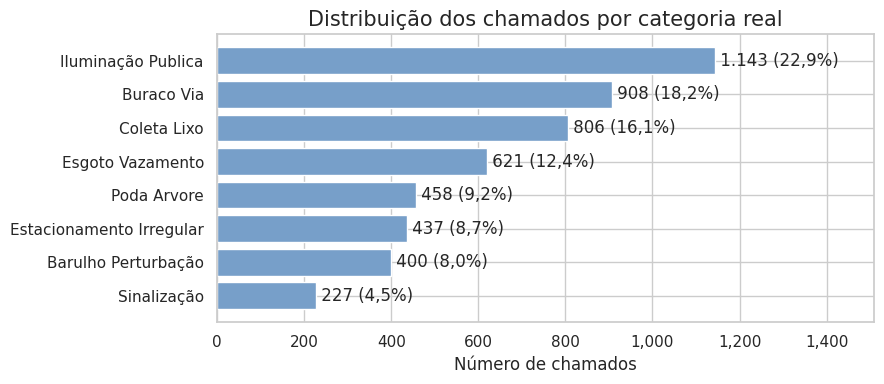

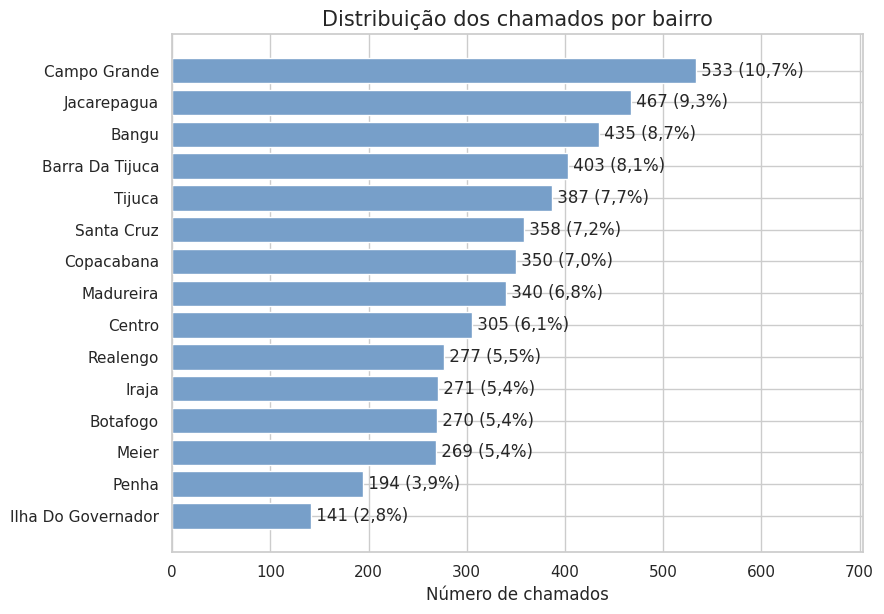

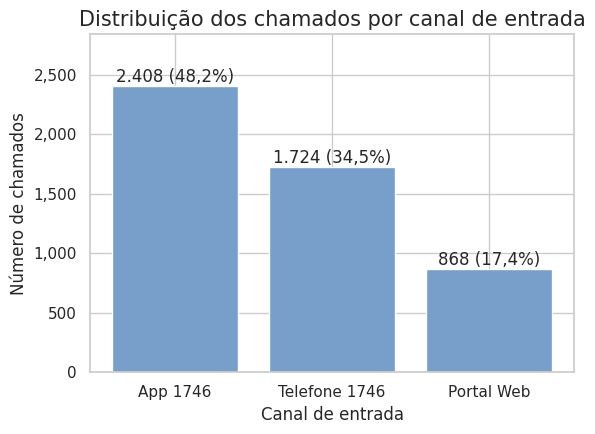

In [96]:
tabela_categorias = tabela_contagem_percentual(df, "categoria_real")
tabela_canais = tabela_contagem_percentual(df, "canal")
tabela_bairros = tabela_contagem_percentual(df, "bairro")

plotar_barras_horizontais(
    tabela_categorias,
    "categoria_real",
    "n",
    "Distribuição dos chamados por categoria real",
    "Número de chamados",
    "02_barras_categorias_reais",
    coluna_percentual="percentual"
)

plotar_barras_horizontais(
    tabela_bairros,
    "bairro",
    "n",
    "Distribuição dos chamados por bairro",
    "Número de chamados",
    "02_barras_bairros",
    top_n=15,
    coluna_percentual="percentual"
)

plotar_barras_verticais(
    tabela_canais,
    "canal",
    "n",
    "Distribuição dos chamados por canal de entrada",
    "Canal de entrada",
    "Número de chamados",
    "02_barras_canais",
    coluna_percentual="percentual"
)


### 2.2 Série Temporal de Chamados

In [60]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

In [107]:
def _melhor_grau(x, y, grau_max=5):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    return min(
        range(1, grau_max + 1),
        key=lambda g: -cross_val_score(
            LinearRegression(),
            PolynomialFeatures(g, include_bias=False).fit_transform(x[:, None]),
            y, cv=kf, scoring="neg_mean_squared_error"
        ).mean())

def plotar_linha_temporal(tabela, coluna_data, coluna_valor, titulo, ylabel, nome_arquivo, curva="auto", grau_max=5):
    tabela = tabela.sort_values(coluna_data)
    x = np.arange(len(tabela))
    y = tabela[coluna_valor].to_numpy()

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(tabela[coluna_data], y, marker="o", label="observado")

    if curva is not None:
        grau = _melhor_grau(x, y, grau_max) if curva == "auto" else curva
        X = PolynomialFeatures(grau, include_bias=False).fit_transform(x[:, None])
        y_pred = LinearRegression().fit(X, y).predict(X)
        ax.plot(tabela[coluna_data], y_pred, "--", linewidth=2, label=f"Tendência (grau {grau})")
        ax.legend()

    ax.set(title=titulo, xlabel="Período", ylabel=ylabel)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    plt.xticks(rotation=45)
    fig.tight_layout()
    save_figure(fig, nome_arquivo)
    plt.show()

def plotar_linhas_temporais_por_grupo(df, coluna_data, coluna_grupo,
                                    titulo, ylabel, nome_arquivo,freq="W", top_n=None):
    dados = df.copy()
    dados[coluna_data] = pd.to_datetime(dados[coluna_data])

    tabela = (dados.groupby([pd.Grouper(key=coluna_data, freq=freq), coluna_grupo])
        .size().reset_index(name="n_chamados"))

    if top_n is not None:
        grupos = (dados[coluna_grupo].value_counts().head(top_n).index)
        tabela = tabela[tabela[coluna_grupo].isin(grupos)]

    tabela_pivot = (tabela.pivot(index=coluna_data, columns=coluna_grupo, values="n_chamados")
        .fillna(0).sort_index())

    tabela_pivot.columns = [pretty_label(coluna) for coluna in tabela_pivot.columns]

    fig, ax = plt.subplots(figsize=(15, 5))
    for coluna in tabela_pivot.columns:
        ax.plot(tabela_pivot.index,tabela_pivot[coluna],marker="o",linewidth=1.8,label=coluna)

    ax.set_title(titulo)
    ax.set_xlabel("Período")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45)
    fig.tight_layout()
    save_figure(fig, nome_arquivo)
    plt.show()

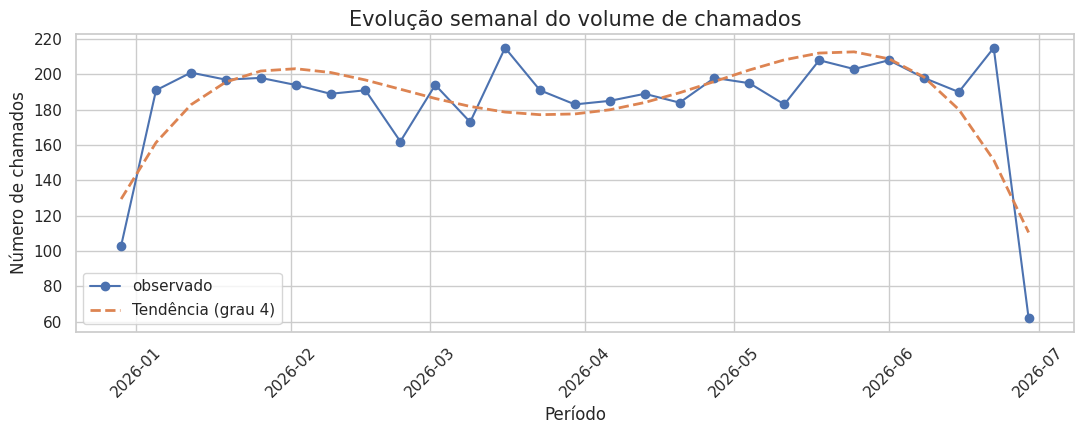

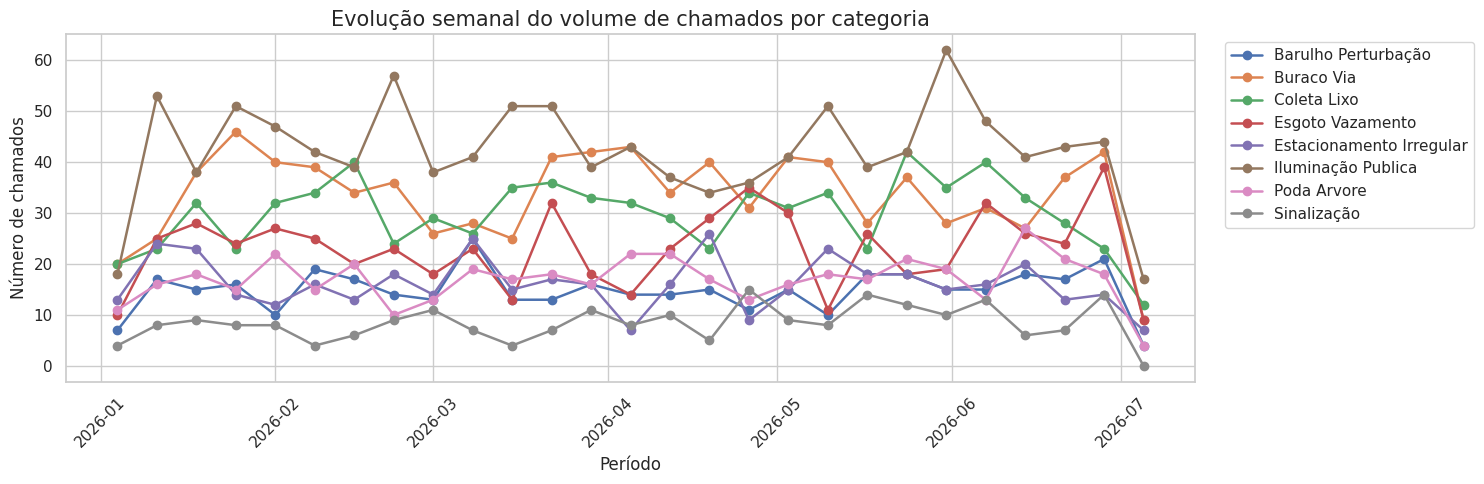

In [ ]:
#tabela_temporal_mes = df.groupby("month").size().reset_index(name="n_chamados")
tabela_temporal_semana = df.groupby("week").size().reset_index(name="n_chamados")

#plotar_linha_temporal(
#    tabela_temporal_mes,
#    "month",
#    "n_chamados",
#    "Evolução mensal do volume de chamados",
#    "Número de chamados",
#    "02_linha_volume_mensal"
#)
plotar_linha_temporal(
    tabela_temporal_semana,
    "week",
    "n_chamados",
    "Evolução semanal do volume de chamados",
    "Número de chamados",
    "02_linha_volume_semanal"
)

plotar_linhas_temporais_por_grupo(
    df,
    "data_abertura",
    "categoria_real",
    "Evolução semanal do volume de chamados por categoria",
    "Número de chamados",
    "02_linha_volume_semanal_por_categoria",
    freq="W"
)

### 2.3 Mapas por Bairros

In [65]:
import requests
from matplotlib.colors import Normalize
from shapely.geometry import Polygon

In [66]:
rio_bairro_url = "https://pgeo3.rio.rj.gov.br/arcgis/rest/services/Cartografia/Limites_administrativos/MapServer/4/query?where=1%3D1&outFields=nome,regiao_adm,codbairro_long&outSR=4326&f=json"
geo_json = requests.get(rio_bairro_url).json()
gdf_bairros = gpd.GeoDataFrame(
    ({
        "code": f["attributes"]["codbairro_long"],
        "regiao_adm": f["attributes"]["regiao_adm"].strip().lower(),
        "bairro": remove_accent(f["attributes"]["nome"].strip().lower()),
        "geometry": Polygon(f["geometry"]["rings"][0]),
    } for f in geo_json["features"]),
    geometry="geometry",
    crs="EPSG:4326",
)
gdf_bairros.head()

,code,regiao_adm,bairro,geometry
0,133,barra da tijuca,grumari,"POLYGON ((-43.50819 -23.03311, -43.50719 -23.0..."
1,137,realengo,jardim sulacap,"POLYGON ((-43.37541 -22.88962, -43.37542 -22.8..."
2,1,portuaria,saude,"POLYGON ((-43.18115 -22.89543, -43.18126 -22.8..."
3,84,madureira,vaz lobo,"POLYGON ((-43.32395 -22.85527, -43.32354 -22.8..."
4,91,ilha do governador,ribeira,"POLYGON ((-43.16461 -22.82115, -43.16459 -22.8..."


In [67]:
codes = {"ilha do governador": [91,92,93,94,95,96,97,98,99,100,101,102,103,104]} # bairros da ilha do governador
var = "bairro" # ou "regiao_adm"
if var == "bairro":
    code_to_bairro = {c: b for b, lst in codes.items() for c in lst}
    gdf_bairros["bairro"] = gdf_bairros["code"].map(code_to_bairro).fillna(gdf_bairros["bairro"])

In [68]:
def juntar_chamados_com_malha(df, gdf, var="bairro"):
    mapa = gdf.merge(df.groupby("bairro").size().rename("n_chamados"),
            left_on=var, right_index=True, how="left").fillna({"n_chamados": 0})
    return mapa

def plotar_mapa_bairros(mapa, titulo, nome_arquivo):
    fig, ax = plt.subplots(figsize=(7,4))
    mapa.plot(
        column="n_chamados",
        cmap="Reds",
        linewidth=0.45,
        edgecolor="0.4",
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Sem correspondência"}
    )
    ax.set_title(titulo)
    ax.set_axis_off()
    save_figure(fig, nome_arquivo)
    plt.show()

def plotar_evolucao_mensal_bairros(df, gdf, title, nome_arquivo):
    periodos = sorted(df["month"].dropna().unique())
    ncols = 3
    nrows = math.ceil(len(periodos) / ncols)
    contagens_global = df.groupby(["month", "bairro"]).size().reset_index(name="n_chamados")
    vmax = contagens_global["n_chamados"].max()
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for i, periodo in enumerate(periodos):
        dados_periodo = df[df["month"] == periodo]
        mapa_periodo = juntar_chamados_com_malha(dados_periodo, gdf, var)
        mapa_periodo.plot(
            column="n_chamados",
            cmap="Reds",
            linewidth=0.45,
            edgecolor="0.45",
            vmin=0,
            vmax=vmax,
            ax=axes[i]
        )
        axes[i].set_title(pd.to_datetime(periodo).strftime("%d/%m/%y"))
        axes[i].set_axis_off()
    for j in range(len(periodos), len(axes)):
        axes[j].set_visible(False)
    normalizador = Normalize(vmin=0, vmax=vmax)
    mapeavel = cm.ScalarMappable(norm=normalizador, cmap="Reds")
    mapeavel.set_array([])
    fig.colorbar(mapeavel, ax=axes[:len(periodos)], cax=fig.add_axes([0.99, 0.20, 0.018, 0.60]))
    fig.suptitle(title, y=0.93, fontsize=15)
    save_figure(fig, nome_arquivo)
    plt.show()

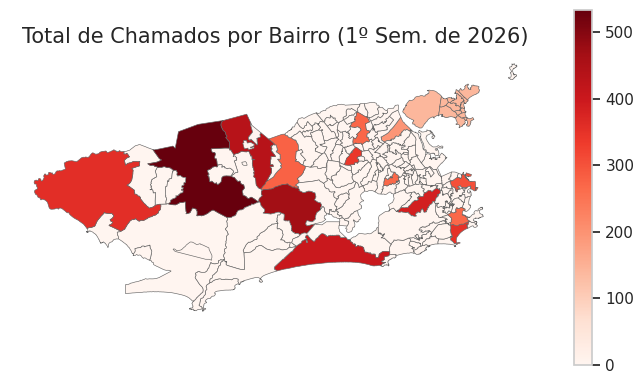

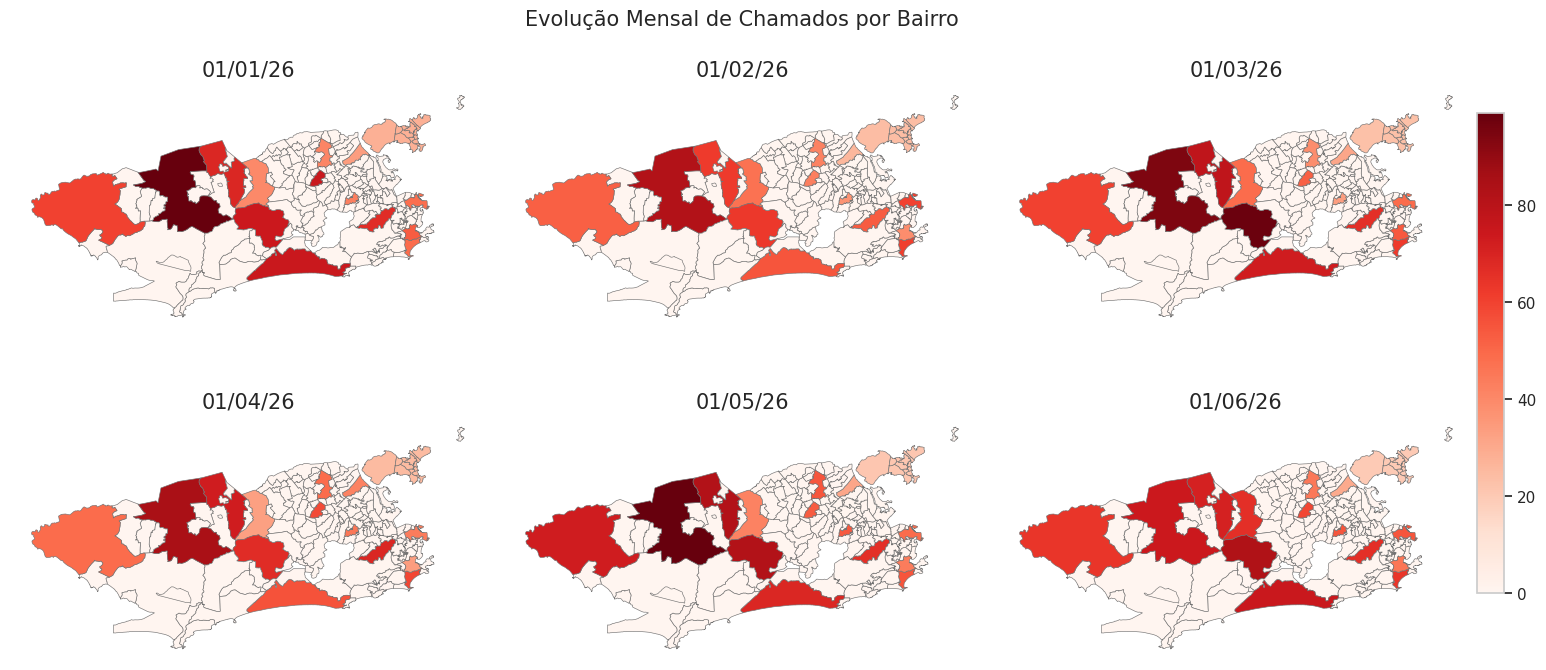

In [69]:
mapa_bairros = juntar_chamados_com_malha(df, gdf_bairros,var)
name = "Bairro" if var == "bairro" else "Região Adm."

plotar_mapa_bairros(
    mapa_bairros,
    f"Total de Chamados por {name} (1º Sem. de 2026)",
    "02_mapa_volume_total_bairros"
)

plotar_evolucao_mensal_bairros(
    df,
    gdf_bairros,
    f"Evolução Mensal de Chamados por {name}",
    "02_mapa_evolucao_mensal_bairros",
)

## 3. Composição das Categorias por Subgrupo

In [ ]:
def aplicar_rotulos_eixo(eixo):
    return [pretty_label(valor) for valor in eixo]

def plotar_heatmap(tabela, titulo, xlabel, ylabel, nome_arquivo, formato=".1f", cmap="Blues"):
    dados = tabela.copy()
    dados.index = aplicar_rotulos_eixo(dados.index)
    dados.columns = aplicar_rotulos_eixo(dados.columns)
    fig, ax = plt.subplots(figsize=(max(8, 0.8 * dados.shape[1]), max(4.5, 0.45 * dados.shape[0])))
    sns.heatmap(dados, annot=True, fmt=formato, cmap=cmap, linewidths=0.5, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    save_figure(fig, nome_arquivo)
    plt.show()

def plotar_barras_empilhadas_percentuais(tabela, titulo, xlabel, ylabel, nome_arquivo, formatar_datas=False):
    dados = tabela.copy()
    dados.index = pd.to_datetime(dados.index).strftime("%m/%y") if formatar_datas else aplicar_rotulos_eixo(dados.index)
    dados.columns = aplicar_rotulos_eixo(dados.columns)
    
    ax = dados.plot(kind="bar", stacked=True, figsize=(11, 5.5))
    ax.set(title=titulo, xlabel=xlabel, ylabel=ylabel)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.tick_params(axis="x", rotation=0)

    fig = ax.get_figure()
    fig.tight_layout()
    save_figure(fig, nome_arquivo)
    plt.show()

In [70]:
categoria_canal_abs = pd.crosstab(df["canal"], df["categoria_real"])
categoria_canal_pct_por_canal = pd.crosstab(df["canal"], df["categoria_real"], normalize="index") * 100
categoria_canal_pct_por_categoria = pd.crosstab(df["categoria_real"], df["canal"], normalize="index") * 100

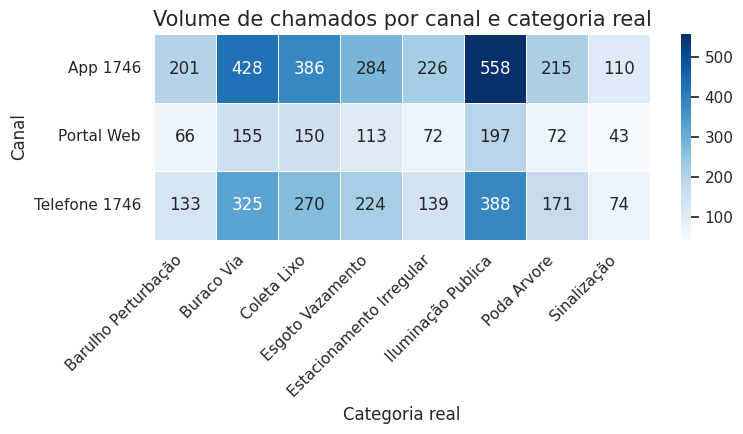

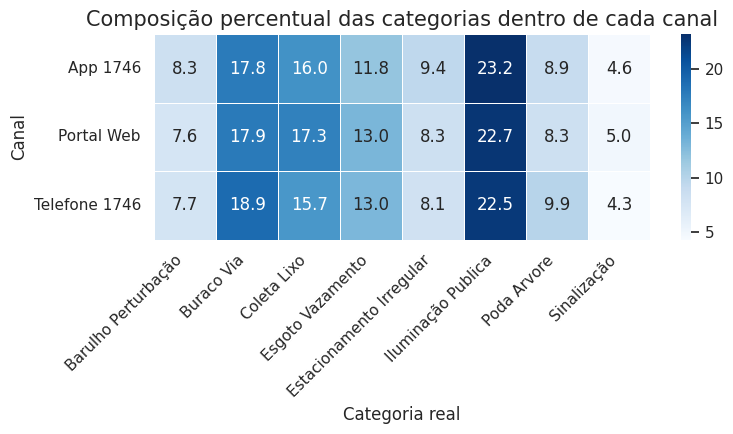

In [71]:
plotar_heatmap(
    categoria_canal_abs,
    "Volume de chamados por canal e categoria real",
    "Categoria real",
    "Canal",
    "03_heatmap_categoria_canal_absoluto",
    formato=".0f",
    cmap="Blues"
)

plotar_heatmap(
    categoria_canal_pct_por_canal,
    "Composição percentual das categorias dentro de cada canal",
    "Categoria real",
    "Canal",
    "03_heatmap_categoria_canal_percentual",
    formato=".1f",
    cmap="Blues"
)

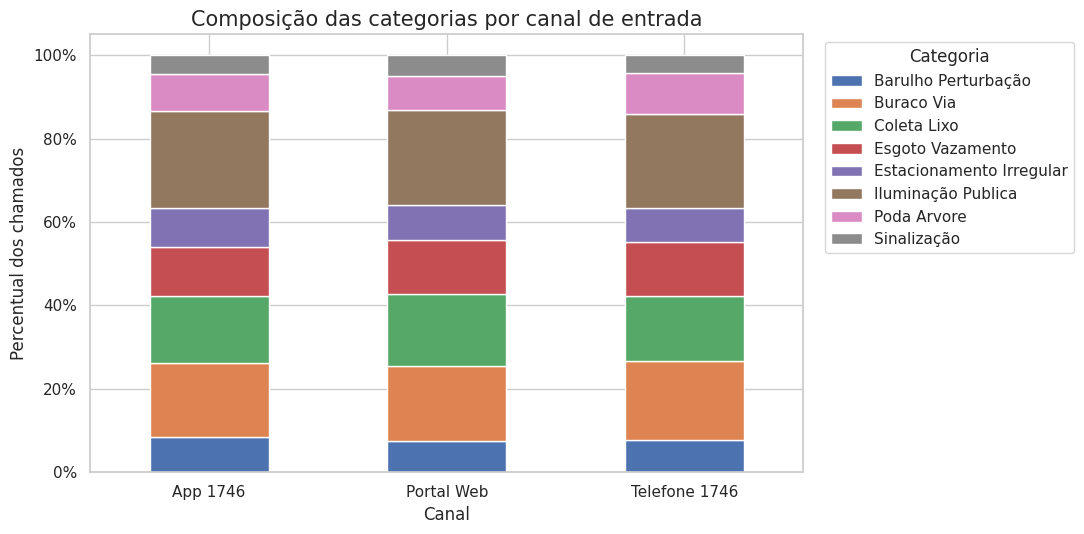

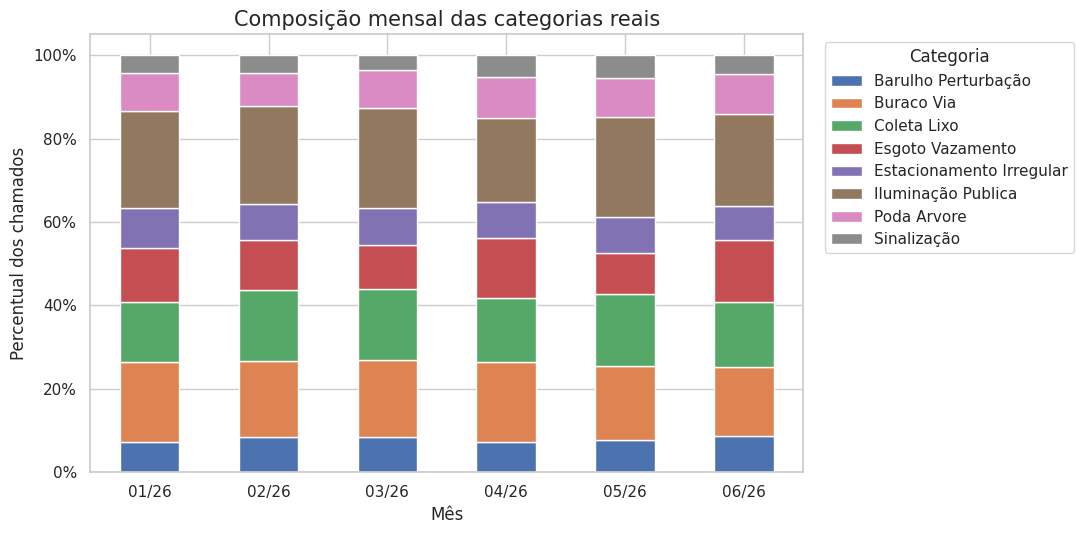

In [72]:
plotar_barras_empilhadas_percentuais(
    categoria_canal_pct_por_canal,
    "Composição das categorias por canal de entrada",
    "Canal",
    "Percentual dos chamados",
    "03_barras_empilhadas_categoria_por_canal"
)

mes_categoria_pct_por_mes = pd.crosstab(df["month"], df["categoria_real"], normalize="index") * 100

plotar_barras_empilhadas_percentuais(
    mes_categoria_pct_por_mes,
    "Composição mensal das categorias reais",
    "Mês",
    "Percentual dos chamados",
    "03_barras_empilhadas_categoria_por_mes",
    True
)

## 4. Características dos Textos e Análise Lexical

## 5. Resultados das Predições